<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/Phase%2013%3A%20Support%20Vector%20Machines%20(SVM)/13_support_vector_machines_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 13: Support Vector Machines (SVM) - The HTRU2 Pulsar Study
## Stage 1: The Astrophysics Data Audit & Statistical Deep Dive

### Objective
Our goal is to architect a classification engine to identify legitimate **Pulsar Stars** from cosmic radio interference (RFI) or noise. Legitimate pulsars are rare neutron stars that emit highly periodic radio pulses. Detecting them requires navigating extreme class imbalance and non-linear entanglements.

We will strictly adhere to a complete data science lifecycle. We will not apply the SVM algorithm until we have thoroughly dissected, cleaned, visualized, and preprocessed the dataset.

### Data Dictionary
This dataset (HTRU2) consists of 8 statistical continuous features derived from processed radio signals:

1.  **Profile_Mean:** Mean of the integrated pulse profile.
2.  **Profile_StDev:** Standard deviation of the integrated profile.
3.  **Profile_Kurtosis:** Excess kurtosis of the integrated profile.
4.  **Profile_Skewness:** Skewness of the integrated profile.
5.  **DM_SNR_Mean:** Mean of the Dispersion Measure (DM) - Signal-to-Noise Ratio (SNR) curve.
6.  **DM_SNR_StDev:** Standard deviation of the DM-SNR curve.
7.  **DM_SNR_Kurtosis:** Excess kurtosis of the DM-SNR curve.
8.  **DM_SNR_Skewness:** Skewness of the DM-SNR curve.
9.  **Target:** Class label (1 = Pulsar Star, 0 = Cosmic Noise/RFI).

In [1]:
#Data loading and basic audit
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PowerTransformer
from ucimlrepo import fetch_ucirepo

# Setting a dark corporate style for intensive visualizations
plt.style.use('dark_background')
plt.rc('font', size=10)
plt.rc('axes', titlesize=14, labelsize=12, grid=False)
plt.rc('figure', facecolor='#161b22')
ax_color = '#161b22'

print("⏳ Ingesting HTRU2 Astrophysical Data via official UCI API...")

# 1. Load Data
htru2 = fetch_ucirepo(id=372)
df = pd.concat([htru2.data.features, htru2.data.targets], axis=1)

# Ensure column names match our pipeline
df.columns = [
    'Profile_Mean', 'Profile_StDev', 'Profile_Kurtosis', 'Profile_Skewness',
    'DM_SNR_Mean', 'DM_SNR_StDev', 'DM_SNR_Kurtosis', 'DM_SNR_Skewness',
    'Target'
]

# 2. Basic Audit
print(f"📊 Dataset Shape: {df.shape[0]} signals, {df.shape[1]-1} features.")
print("\nTarget Class Distribution:")
print(df['Target'].value_counts().rename({0: 'Cosmic Noise (0)', 1: 'Pulsar Star (1)'}))

# 3. Check for Missing Values & Duplicates
print(f"\nMissing Values Audit:")
null_count = df.isnull().sum().sum()
if null_count == 0:
    print("✅ No missing values detected across all 8 features.")
else:
    print(f"⚠️ {null_count} total missing values found. Cleaning required.")

duplicate_count = df.duplicated().sum()
print(f"✅ Found {duplicate_count} exact duplicate rows.")

df.head(5)

⏳ Ingesting HTRU2 Astrophysical Data via official UCI API...
📊 Dataset Shape: 17898 signals, 8 features.

Target Class Distribution:
Target
Cosmic Noise (0)    16259
Pulsar Star (1)      1639
Name: count, dtype: int64

Missing Values Audit:
✅ No missing values detected across all 8 features.
✅ Found 0 exact duplicate rows.


,Profile_Mean,Profile_StDev,Profile_Kurtosis,Profile_Skewness,DM_SNR_Mean,DM_SNR_StDev,DM_SNR_Kurtosis,DM_SNR_Skewness,Target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


## Stage 2: Univariate Analysis - Feature Dissection

We must analyze the statistical distribution of each feature independently. SVM performance is highly dependent on feature scaling and distribution shape. We are specifically checking for extreme **skewness** and **outliers** in our 8 continuous features. Heavy skewness (indicated by skewness values > 1.0 or < -1.0) can severely bias the algorithm.

Dissecting Feature Distributions and Skewness...


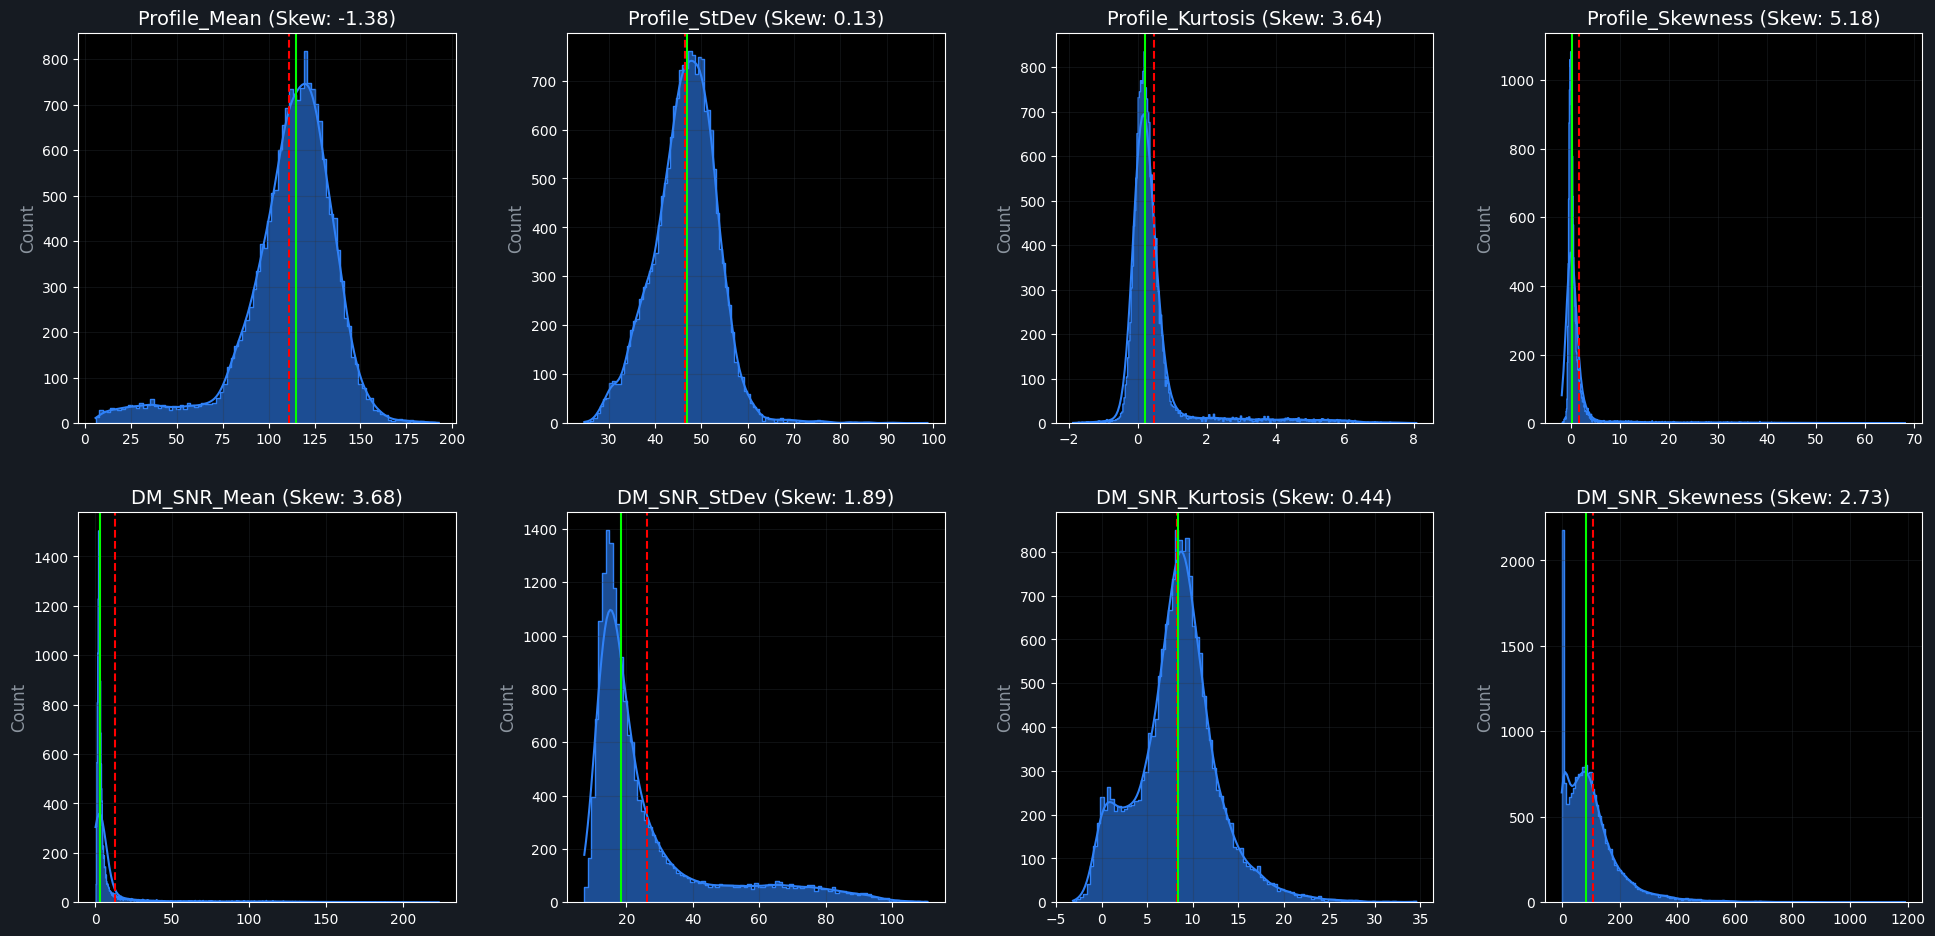

Univariate dissection complete.


In [2]:
print("Dissecting Feature Distributions and Skewness...")

# Define features for visual looping
continuous_features = [f for f in df.columns if f != 'Target']

# Generate intensive Histograms with KDE for all 8 features
fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor=ax_color)
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    # Plot histogram + Kernel Density Estimate
    sns.histplot(df[feature], ax=axes[i], kde=True, color='#2f81f7',
                 alpha=0.6, element='step', label='Data')

    # Calculate Skewness to quantify the asymmetry
    feature_skewness = df[feature].skew()
    axes[i].set_title(f"{feature} (Skew: {feature_skewness:.2f})", color='white')
    axes[i].set_ylabel("Count", color='#8b949e')
    axes[i].set_xlabel("", color='#8b949e')

    # Add mean/median lines to visualize skewness effect
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label='Mean')
    axes[i].axvline(median_val, color='lime', linestyle='-', label='Median')
    axes[i].grid(color='#30363d', linestyle='-', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

print("Univariate dissection complete.")

#Discussion:
This visualization provides a clear statistical audit of the 8 continuous features in the HTRU2 dataset, revealing severe structural imbalances that must be corrected before training. The red dashed line represents the Mean, and the green solid line represents the Median.  

When the mean and median separate significantly, it indicates that extreme outliers are stretching the data distribution in one direction.   

Extreme Right Skew (Positive Skew): Features like Profile_Skewness (Skew: 5.18), DM_SNR_Mean (Skew: 3.68), and Profile_Kurtosis (Skew: 3.64) have massive right-hand tails. The majority of the data is compressed into the left side of the graph, while a few extreme high values drag the mean (red line) far to the right of the median (green line).   

Moderate to High Skew: DM_SNR_Skewness (2.73) and DM_SNR_StDev (1.89) also show significant rightward stretching.   Left Skew (Negative Skew): Profile_Mean (-1.38) is the only feature with a prominent left-hand tail, where lower extreme values pull the mean behind the median.   

Near-Normal Distributions: Only Profile_StDev (0.13) and DM_SNR_Kurtosis (0.44) resemble a balanced, symmetrical bell curve where the mean and median are closely aligned.  

## Stage 3: Bivariate Analysis - Identifying Separability

Now we dissect how our statistical features act differently when measuring Cosmic Noise (Target 0) versus Pulsar Stars (Target 1). We are looking for high class-conditional variance—which features provide the cleanest mathematical separation? This visualization is the perfect way to validate which features the SVM algorithm will rely on most heavily.

### Visualizing Separability with Violin Plots
Violin plots are excellent for this task because they combine a boxplot with a KDE plot, showing us the density distribution of the data conditional on the Target Class.

Analyzing Feature Separability by Class...


AttributeError: FillBetweenPolyCollection.set() got an unexpected keyword argument 'grid'

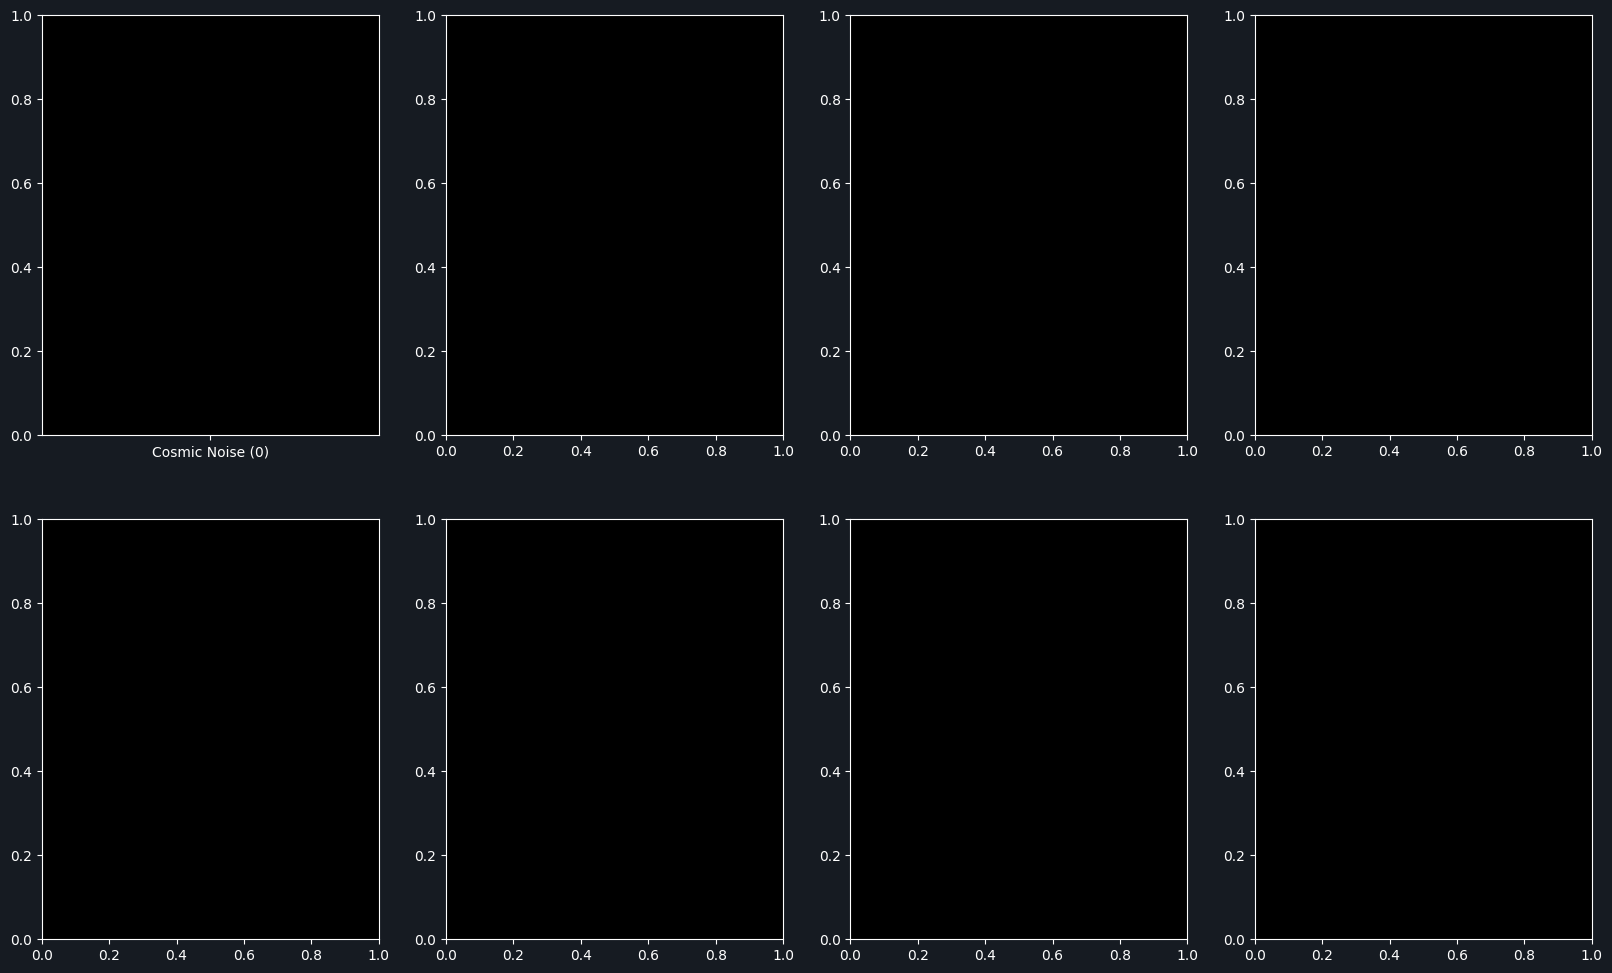

In [3]:
print("Analyzing Feature Separability by Class...")

# Re-map target to descriptive labels strictly for visualization
df_viz = df.copy()
df_viz['Label'] = df_viz['Target'].map({0: 'Cosmic Noise (0)', 1: 'Pulsar Star (1)'})

# Generate intensive 2x4 grid of Violin Plots
fig, axes = plt.subplots(2, 4, figsize=(20, 12), facecolor=ax_color)
axes = axes.flatten()

# Custom color palette (Cool colors for noise, Warm for stars)
pulsar_colors = {'Cosmic Noise (0)': '#5e5e5e', 'Pulsar Star (1)': '#f72f81'}

for i, feature in enumerate(continuous_features):
    # Plot violin: Shows distribution shape and class conditonal variance
    sns.violinplot(x='Label', y=feature, data=df_viz, ax=axes[i],
                   palette=pulsar_colors, hue='Label', legend=False,
                   inner='quartile', linewidth=1, grid=False)

    axes[i].set_title(f"{feature} Separability", color='white')
    axes[i].set_ylabel("", color='#8b949e')
    axes[i].set_xlabel("", color='#8b949e')
    axes[i].tick_params(colors='white')
    axes[i].grid(color='#30363d', linestyle='-', alpha=0.3)

plt.tight_layout(pad=4.0)
plt.show()

print("Bivariate analysis complete.")